### Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

#### Load Data

In [3]:
#loading the data
df = pd.read_csv('../data/kenya.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


#### Data Parsing

In [4]:
#Add a country column with the country name
df['country'] = 'Kenya'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


In [5]:
#Convert the YEAR and DOY columns to a proper datetime format
df['date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'], format="%Y%j")
df['month'] = df['date'].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


### Summary Statistics & Missing-Value Report

In [6]:
#Replace the -999 values with NaN
df.replace(-999, np.nan, inplace=True)
df.describe()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


In [7]:
# Check for duplicates
df.duplicated().sum()

0

In [8]:
#Numeric columns describe
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [9]:
# Compute the percentage of missing values in each column
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
month          0
dtype: int64

#### Outlier Detection & Basic Cleaning

In [10]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [11]:
z_scores = np.abs(stats.zscore(df[cols_to_check]))
outliers_mask = (z_scores > 3).any(axis=1)
print(f"\n Rows flagged as outliers: {outliers_mask.sum()}")


 Rows flagged as outliers: 121


In [12]:
# Remove outliers
df_clean = df[~outliers_mask].copy()

In [13]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Remaining negatives: {(df_clean[cols_to_check] < 0).sum().sum()}")

Original rows: 4108
Cleaned rows: 3987
Remaining negatives: 0


#### Handle Missing Data


In [14]:
df_filtered = df[df.isna().mean(axis=1) <= 0.3]
print(f"Original rows: {len(df)}")
print(f"Filtered rows: {len(df_filtered)}")


Original rows: 4108
Filtered rows: 4108


## Export Data

In [15]:
df_clean.to_csv('../data/kenya_clean.csv', index=False)

### Time Series Analysis

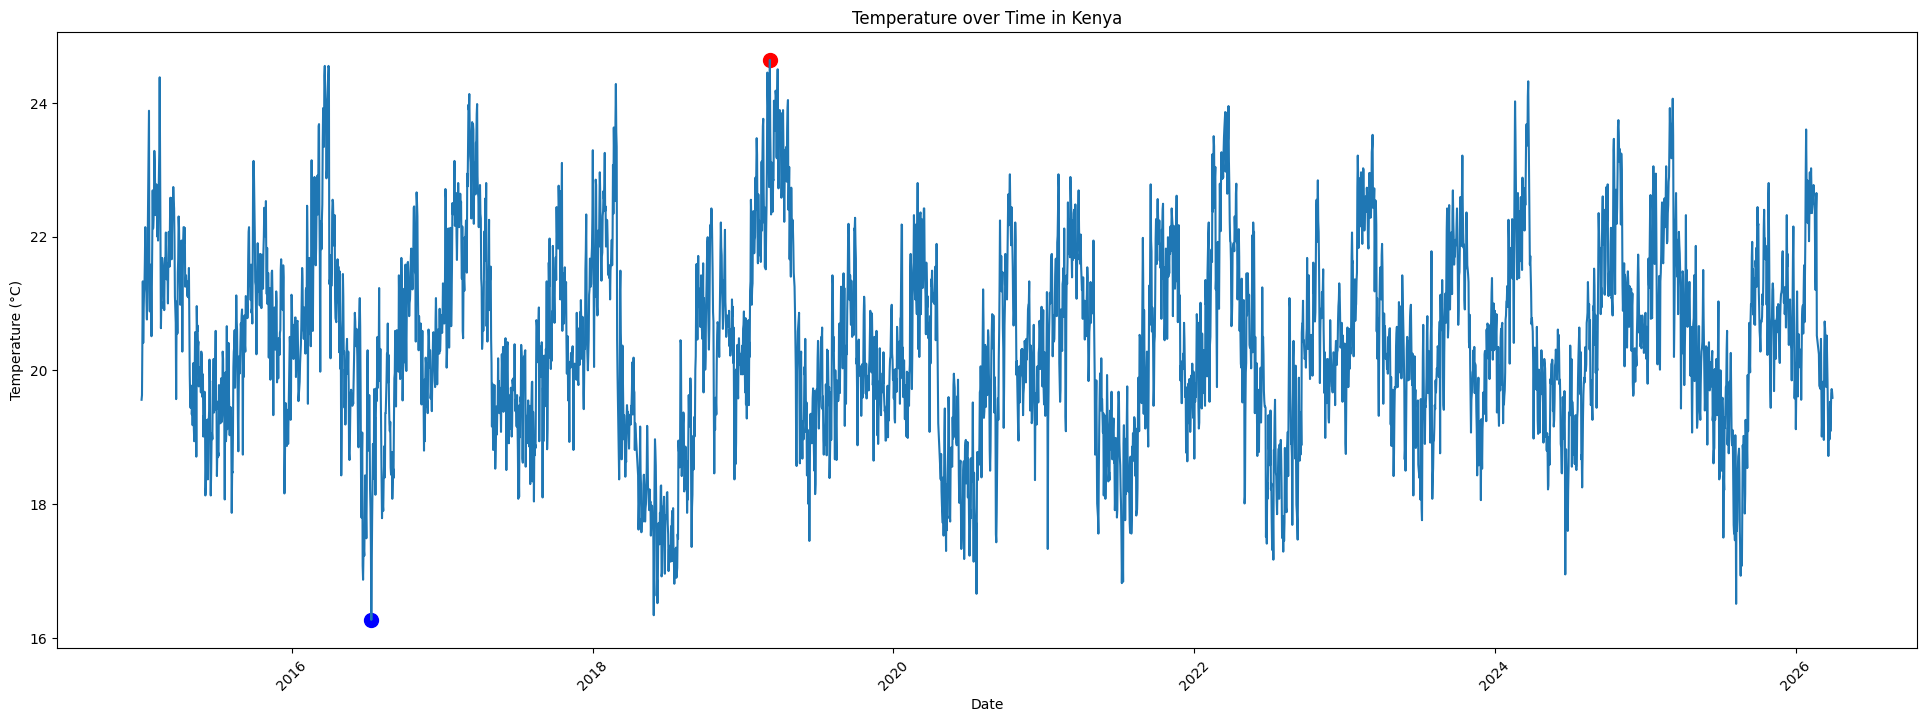

In [16]:
plt.figure(figsize=(24,8))

plt.plot('date', 'T2M', data=df_clean)

# Add Title and Labels
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.title('Temperature over Time in Kenya')

# Rotate the x-axis
plt.xticks(rotation=45)

# Annotate the highest and lowest temperature
highest_temp_idx = df_clean['T2M'].idxmax()
lowest_temp_idx = df_clean['T2M'].idxmin()

plt.scatter(df_clean['date'].loc[highest_temp_idx], df_clean['T2M'].loc[highest_temp_idx], color='red', marker='o', s=[100], label='Max Temp')

plt.scatter(df_clean['date'].loc[lowest_temp_idx], df_clean['T2M'].loc[lowest_temp_idx], color='blue', marker='o', s=[100], label='Max Temp')

plt.show()

### Correlation & Relationship Analysis

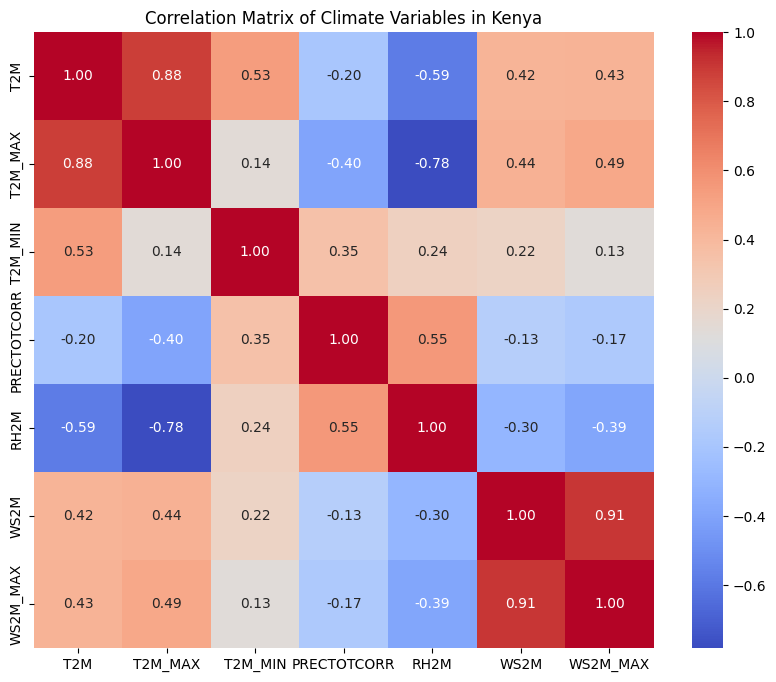

In [17]:
# Heatmap of correlations across all numeric columns
corr_matrix = df_clean[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Climate Variables in Kenya')
plt.show()

### Scatter Plots 

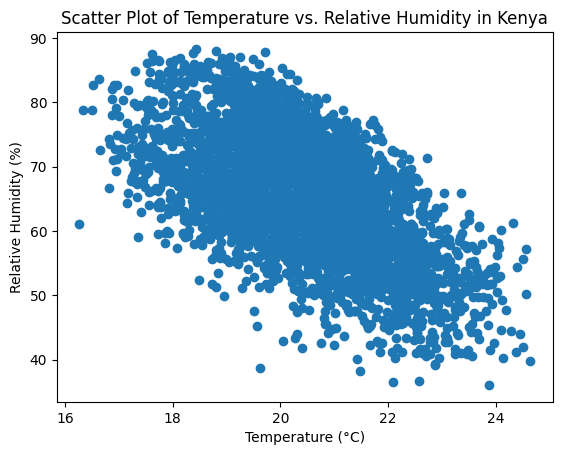

In [18]:
#scatter plot T2M vs RH2M

plt.scatter(df_clean['T2M'], df_clean['RH2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Kenya')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

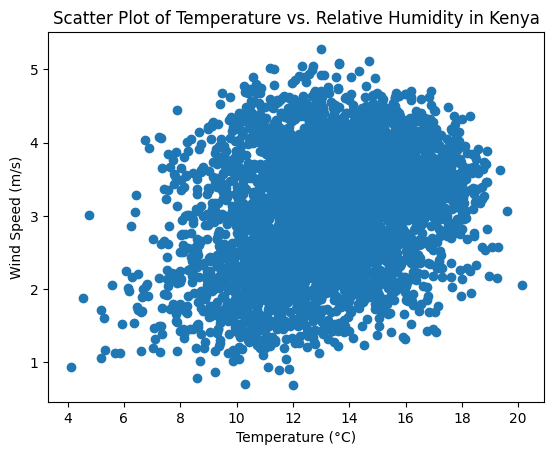

In [19]:
#scatter plot T2M_RANGE vs WS2M

plt.scatter(df_clean['T2M_RANGE'], df_clean['WS2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Kenya')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

### Distribution Analysis

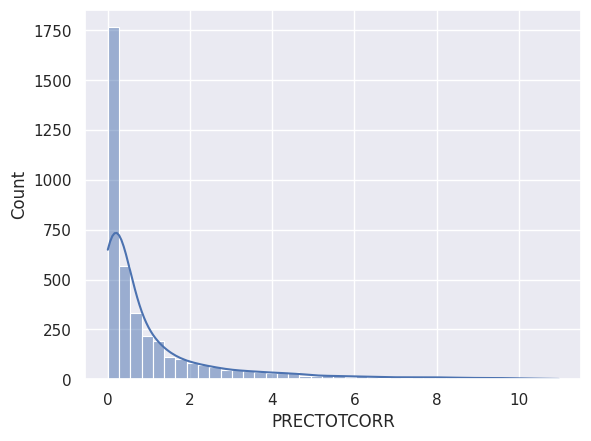

In [20]:
sns.set_theme(style="darkgrid")
sns.histplot(df_clean['PRECTOTCORR'], bins=40, kde=True)

plt.show()

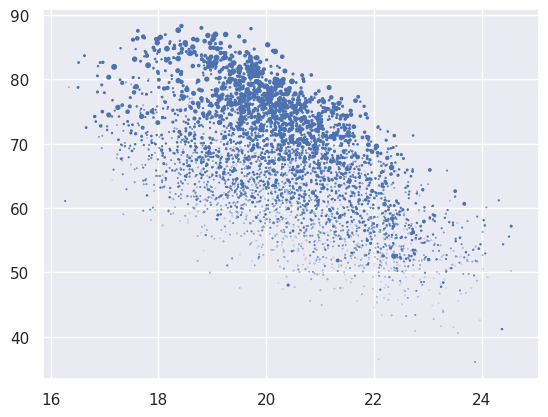

In [21]:
plt.scatter(x='T2M', y='RH2M', data=df_clean, s='PRECTOTCORR')